<a href="https://colab.research.google.com/github/soleildayana/Apophis-Asteroid-Project/blob/main/main.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Aproximación de (99942) Apophis a la Tierra en abril de 2029  
## Notebook principal (reporte de investigación en Mecánica Celeste)


El encuentro cercano de **(99942) Apophis** con la Tierra en abril de 2029 es uno de los eventos más relevantes de dinámica de NEAs en el siglo XXI. Desde una perspectiva de Mecánica Celeste, este caso es especialmente valioso porque combina:

1. **Dinámica kepleriana de fondo** (movimiento heliocéntrico dominante).
2. **Perturbaciones multi-cuerpo** (Tierra, Luna y planetas interiores/exteriores).
3. **Interés aplicado** en evaluación de riesgo, diseño de campañas de observación y validación de modelos numéricos.

En la literatura moderna de dinámica orbital y defensa planetaria, el análisis de encuentros cercanos suele estructurarse de forma jerárquica: modelos simples (2 cuerpos), modelos intermedios (3 cuerpos/CRTBP) y modelos N-cuerpos de alta fidelidad con efemérides reales. Este notebook sigue ese esquema para mostrar, en una narrativa única, cómo evoluciona la interpretación física al incrementar la complejidad del modelo.


## Pregunta de investigación y estrategia

**Pregunta central:** ¿cómo cambia la estimación de la distancia mínima Tierra–Apophis y la interpretación dinámica del encuentro 2029 al pasar de modelos simplificados a un modelo N-cuerpos completo?

**Estrategia numérica resumida:**

- Construir condiciones iniciales desde **NASA Horizons** en marco baricéntrico.
- Trabajar en unidades canónicas astronómicas (\(G=1\), longitud en AU, tiempo en UT).
- Comparar familias de modelos (SEA \(
ightarrow\) SEMA \(
ightarrow\) SEMAJ \(
ightarrow\) SEMAJV \(
ightarrow\) 9 cuerpos).
- Refinar temporalmente la ventana alrededor del mínimo de distancia.
- Relacionar resultados con herramientas teóricas: problema de dos cuerpos, CRTBP/Jacobi y ecuaciones de Gauss.


## Marco teórico esencial

### 1) Problema de N cuerpos

La dinámica gravitacional para cada cuerpo \(i\) se modela por:

$
\ddot{\mathbf r}_i = -\,G\sum_{j
eq i} m_j\,
rac{\mathbf r_i-\mathbf r_j}{\|\mathbf r_i-\mathbf r_j\|^3}.
$

En este proyecto usamos unidades canónicas para integrar de forma estable y comparar modelos de distinta complejidad.

### 2) Magnitud observacional clave

La variable principal es la distancia Tierra–Apophis:

$
d_{EA}(t)=\|\mathbf r_{A}(t)-\mathbf r_{E}(t)\|,
$

cuyo mínimo define el máximo acercamiento en la ventana 2028–2029.

### 3) CRTBP

Comparar \(C_J\) con los valores en \(L_1\) y \(L_2\) permite interpretar apertura/cierre de regiones energéticas.

### 4) Ecuaciones de Gauss para variación orbital

Para componentes perturbadoras en la terna local \((\hat r,\hat s,\hat w)\), dos ecuaciones relevantes son:

[/
rac{di}{dt}=
rac{r\cos(\omega+f)}{h}\,W,
\qquad

rac{d\Omega}{dt}=
rac{r\sin(\omega+f)}{h\sin i}\,W.
/]

Estas ecuaciones conectan directamente perturbaciones gravitacionales con cambios en la geometría orbital.


## 0. Preparación del entorno

Primero instalamos/importamos dependencias y fijamos constantes para asegurar que todo el notebook pueda ejecutarse con **Run All** de forma reproducible.


In [1]:
%pip install -Uq pymcel scipy

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.1/62.1 kB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.2/35.2 MB 21.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.1/11.1 MB 54.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 23.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 26.6 MB/s eta 0:00:00


Importamos librerías de cálculo, visualización e integración; también definimos utilidades para descargar estados de Horizons y construir sistemas N-cuerpos sin duplicar código.


In [2]:
import warnings
from datetime import datetime, timedelta

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import brentq
from scipy.integrate import cumulative_trapezoid

import pymcel as pc

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')


Bienvenido a PyMCel v0.9.18 ¡al infinito y más allá!


Configuramos unidades canónicas, masas y funciones auxiliares. Esto centraliza supuestos físicos (\(G=1\), conversión AU/día \(
ightarrow\) AU/UT, etc.) para todas las secciones del reporte.


In [3]:
# --- Unidades canónicas ---
AU_m = pc.constantes.au
AU_km = AU_m / 1e3
M_sun_kg = pc.constantes.M_sun
G_SI = pc.constantes.G
R_Earth_km = 6371.0

UT_s = np.sqrt(AU_m**3 / (G_SI * M_sun_kg))
UT_days = UT_s / 86400.0
vel_unit = AU_km / UT_s

# --- Parámetros gravitacionales (km^3/s^2), consistentes con notebooks del repo ---
GM = {
    'Sol':      1.32712440018e11,
    'Mercurio': 2.2032e4,
    'Venus':    3.24858592e5,
    'Tierra':   3.986004418e5,
    'Luna':     4.9048695e3,
    'Marte':    4.282837e4,
    'Jupiter':  1.26686534e8,
    'Saturno':  3.7931187e7,
}
M_apophis_kg = 2.7e10

masas_canon = {k: v / GM['Sol'] for k, v in GM.items()}
masas_canon['Apophis'] = M_apophis_kg / M_sun_kg

ids_horizons = {
    'Sol': '10', 'Mercurio': '199', 'Venus': '299', 'Tierra': '399',
    'Luna': '301', 'Marte': '499', 'Jupiter': '599', 'Saturno': '699',
    'Apophis': '99942'
}

print(f'UT = {UT_days:.6f} días | 1 AU/UT = {vel_unit:.6f} km/s')


def extraer_estado_canonico(tabla_o_dict):
    if isinstance(tabla_o_dict, dict):
        return np.array(tabla_o_dict['r'], dtype=float), np.array(tabla_o_dict['v'], dtype=float)
    row = tabla_o_dict[0]
    r = np.array([float(row['x']), float(row['y']), float(row['z'])], dtype=float)
    v = np.array([float(row['vx']), float(row['vy']), float(row['vz'])], dtype=float)
    return r, v * UT_days  # AU/UT


def estados_fallback_aprox():
    """Estados aproximados en canónicas para ejecutar sin acceso a Horizons."""
    deg = np.pi / 180.0

    elems = {
        'Mercurio': (0.3871, 0.2056, 7.0,   48.3,  29.1, 250.0),
        'Venus':    (0.7233, 0.0068, 3.39,  76.7,  54.9,  50.0),
        'Tierra':   (1.0000, 0.0167, 0.00, -11.3, 102.9, 100.0),
        'Marte':    (1.5237, 0.0934, 1.85,  49.6, 286.5, 355.0),
        'Jupiter':  (5.2044, 0.0489, 1.30, 100.5, 273.9,  30.0),
        'Saturno':  (9.5826, 0.0565, 2.49, 113.7, 339.4, 320.0),
        'Apophis':  (0.9224, 0.1911, 3.34, 204.4, 126.4, 170.0),
    }

    estados = {'Sol': {'r': [0, 0, 0], 'v': [0, 0, 0]}}
    for nombre, (a, e, i, W, w, f) in elems.items():
        p = a * (1 - e**2)
        est = pc.elementos_a_estado(1.0, np.array([p, e, i*deg, W*deg, w*deg, f*deg]))
        estados[nombre] = {'r': est[:3], 'v': est[3:]}

    # Luna aproximada alrededor de la Tierra (circular local)
    rE = np.array(estados['Tierra']['r'])
    vE = np.array(estados['Tierra']['v'])
    er = rE / np.linalg.norm(rE)
    zhat = np.array([0.0, 0.0, 1.0])
    et = np.cross(zhat, er)
    et = et / np.linalg.norm(et)

    rho = 384400.0 / AU_km
    phi = 40.0 * deg
    r_rel = rho * (np.cos(phi) * er + np.sin(phi) * et)

    v_rel_mag = np.sqrt((masas_canon['Tierra'] + masas_canon['Luna']) / rho)
    v_rel = v_rel_mag * (-np.sin(phi) * er + np.cos(phi) * et)

    estados['Luna'] = {'r': rE + r_rel, 'v': vE + v_rel}
    return estados


def descargar_estados(epoch, nombres):
    estados = {}
    try:
        for nombre in nombres:
            estados[nombre] = pc.consulta_horizons(
                id=ids_horizons[nombre], location='@0', epochs=epoch,
                datos='vectors', propiedades='default'
            )[0]
        print('Consulta Horizons completada correctamente.')
    except Exception as e:
        print(f'Advertencia: no se pudo consultar Horizons ({e}).')
        print('Se usarán estados aproximados locales para mantener la ejecución completa del notebook.')
        fallback = estados_fallback_aprox()
        for nombre in nombres:
            estados[nombre] = fallback[nombre]
    return estados


def construir_sistema(orden, estados):
    sistema = []
    for nombre in orden:
        r, v = extraer_estado_canonico(estados[nombre])
        sistema.append(dict(m=masas_canon[nombre], r=list(r), v=list(v)))
    return sistema


def correr_modelo(orden, estados, duracion_dias=547, n_pasos=1800):
    ts = np.linspace(0.0, duracion_dias / UT_days, n_pasos)
    idx = {n: k for k, n in enumerate(orden)}
    sistema = construir_sistema(orden, estados)
    rs, vs, rps, vps, const = pc.ncuerpos_solucion(sistema, ts)
    d = np.linalg.norm(rs[idx['Tierra']] - rs[idx['Apophis']], axis=1)
    i_min = int(np.argmin(d))
    return {
        'orden': orden, 'idx': idx, 'ts': ts, 'rs': rs, 'vs': vs,
        'rps': rps, 'vps': vps, 'const': const, 'dist': d,
        'i_min': i_min, 'd_min_AU': float(d[i_min])
    }


UT = 58.132441 días | 1 AU/UT = 29.784692 km/s


## 1. Simulación principal y convergencia entre versiones de modelo

En este bloque sintetizamos el núcleo del proyecto: ejecutar varias versiones del sistema y comparar la estimación de \(d_{\min}\). Esto permite evaluar qué tanto cambia el resultado al añadir perturbadores gravitacionales.


In [4]:
T0_STR = '2028-01-01'
t0_date = datetime(2028, 1, 1)

orden_superset = ['Sol', 'Mercurio', 'Venus', 'Tierra', 'Luna', 'Marte', 'Jupiter', 'Saturno', 'Apophis']
estados_t0 = descargar_estados(T0_STR, orden_superset)

modelos = {
    'SEA (3C)': ['Sol', 'Tierra', 'Apophis'],
    'SEMA (4C)': ['Sol', 'Tierra', 'Luna', 'Apophis'],
    'SEMAJ (5C)': ['Sol', 'Tierra', 'Luna', 'Jupiter', 'Apophis'],
    'SEMAJV (6C)': ['Sol', 'Tierra', 'Luna', 'Jupiter', 'Venus', 'Apophis'],
    '9C final': ['Sol', 'Mercurio', 'Venus', 'Tierra', 'Luna', 'Marte', 'Jupiter', 'Saturno', 'Apophis'],
}

resultados = {}
for nombre, orden in modelos.items():
    resultados[nombre] = correr_modelo(orden, estados_t0, duracion_dias=547, n_pasos=1700)

tabla = []
for nombre, res in resultados.items():
    i = res['i_min']
    fecha = t0_date + timedelta(days=float(res['ts'][i] * UT_days))
    d_km = res['d_min_AU'] * AU_km
    tabla.append([nombre, res['d_min_AU'], d_km, fecha])

df_conv = pd.DataFrame(tabla, columns=['Modelo', 'd_min_AU', 'd_min_km', 'fecha_min'])
df_conv = df_conv.sort_values('d_min_km').reset_index(drop=True)
df_conv


Consulta Horizons completada correctamente.


,Modelo,d_min_AU,d_min_km,fecha_min
0,9C final,0.000593,88704.096491,2029-04-13 18:21:49.476162
1,SEMAJV (6C),0.000594,88829.486444,2029-04-13 18:21:49.476162
2,SEMA (4C),0.000623,93246.481480,2029-04-13 18:21:49.476162
3,SEMAJ (5C),0.000638,95453.962175,2029-04-13 18:21:49.476162
4,SEA (3C),0.005014,750032.948995,2029-04-14 09:49:03.143025


Graficamos la convergencia para visualizar de manera directa el efecto de incorporar más física al sistema. La expectativa es que los modelos más completos estabilicen la predicción de distancia mínima.


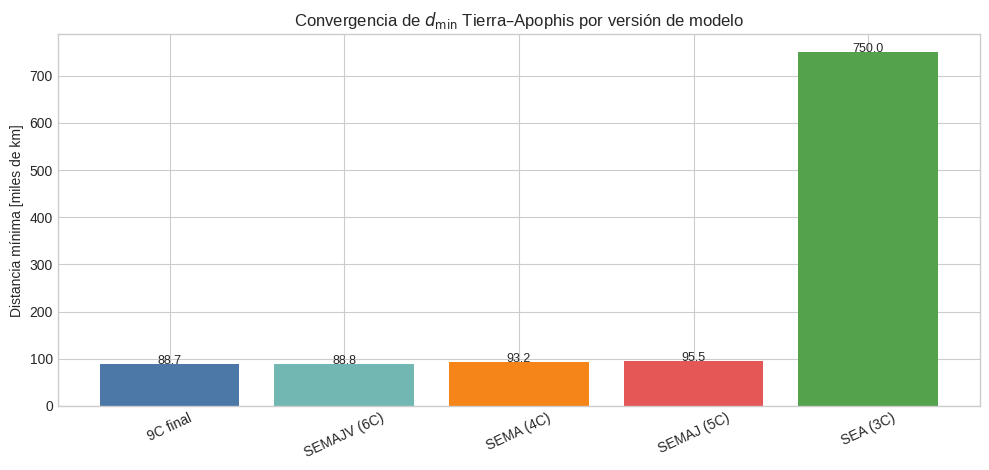

In [5]:
fig, ax = plt.subplots(figsize=(10, 4.8))
ax.bar(df_conv['Modelo'], df_conv['d_min_km'] / 1000, color=['#4c78a8', '#72b7b2', '#f58518', '#e45756', '#54a24b'])
ax.set_ylabel('Distancia mínima [miles de km]')
ax.set_title('Convergencia de $d_{\min}$ Tierra–Apophis por versión de modelo')
ax.tick_params(axis='x', rotation=25)
for i, v in enumerate(df_conv['d_min_km'] / 1000):
    ax.text(i, v + 0.6, f'{v:,.1f}', ha='center', fontsize=9)
plt.tight_layout()
plt.show()


Ahora tomamos el modelo final de 9 cuerpos y realizamos un **refinamiento temporal local** alrededor del mínimo de la corrida base. Esta etapa mejora la resolución en fecha y distancia del encuentro.


In [6]:
res9 = resultados['9C final']
idx9 = res9['idx']

MARGEN_DIAS = 30
N_FINO = 4200

ts = res9['ts']
rs = res9['rs']
vs = res9['vs']
i_min = res9['i_min']

# Ventana local en UT
t_ini = max(0.0, ts[i_min] - MARGEN_DIAS / UT_days)
t_fin = min(ts[-1], ts[i_min] + MARGEN_DIAS / UT_days)
i_restart = int(np.argmin(np.abs(ts - t_ini)))

orden9 = res9['orden']
sistema_fino = []
for nombre in orden9:
    k = idx9[nombre]
    sistema_fino.append(dict(m=masas_canon[nombre], r=list(rs[k, i_restart, :]), v=list(vs[k, i_restart, :])))

ts_rel = np.linspace(0.0, t_fin - t_ini, N_FINO)
rs_f, vs_f, _, _, const_f = pc.ncuerpos_solucion(sistema_fino, ts_rel)

dist_f = np.linalg.norm(rs_f[idx9['Tierra']] - rs_f[idx9['Apophis']], axis=1)
i_min_f = int(np.argmin(dist_f))

fecha_min_f = t0_date + timedelta(days=float((t_ini + ts_rel[i_min_f]) * UT_days))
d_min_f_AU = float(dist_f[i_min_f])
d_min_f_km = d_min_f_AU * AU_km
d_min_f_RE = d_min_f_km / R_Earth_km

print(f'Distancia mínima refinada = {d_min_f_AU:.6e} AU = {d_min_f_km:,.0f} km = {d_min_f_RE:.2f} R_⊕')
print(f'Fecha refinada            = {fecha_min_f:%Y-%m-%d %H:%M UTC}')


Distancia mínima refinada = 2.571499e-04 AU = 38,469 km = 6.04 R_⊕
Fecha refinada            = 2029-04-13 20:14 UTC


Mostramos tres visualizaciones centrales del modelo final: (i) curva de distancia con zoom en el mínimo, (ii) conservación de energía como control numérico y (iii) trayectorias XY para contexto orbital global.


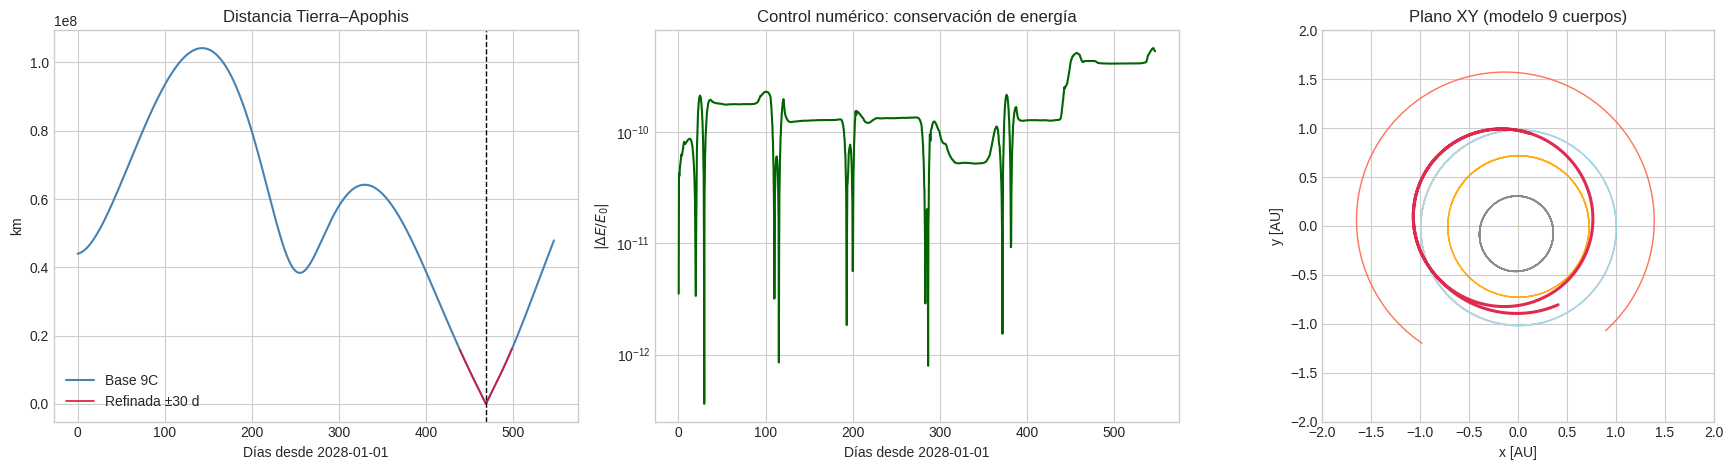

In [7]:
dias = ts * UT_days
dias_f = (t_ini + ts_rel) * UT_days

E9 = res9['const']['K'] + res9['const']['U']
err_E = np.abs((E9 - E9[0]) / E9[0])

fig, axes = plt.subplots(1, 3, figsize=(18, 4.8))

# Distancia
axes[0].plot(dias, res9['dist'] * AU_km, color='steelblue', lw=1.5, label='Base 9C')
axes[0].plot(dias_f, dist_f * AU_km, color='crimson', lw=1.2, label='Refinada ±30 d')
axes[0].axvline(dias_f[i_min_f], color='k', ls='--', lw=1)
axes[0].set_title('Distancia Tierra–Apophis')
axes[0].set_xlabel('Días desde 2028-01-01')
axes[0].set_ylabel('km')
axes[0].legend()

# Energía
axes[1].semilogy(dias[1:], err_E[1:] + 1e-20, color='darkgreen')
axes[1].set_title('Control numérico: conservación de energía')
axes[1].set_xlabel('Días desde 2028-01-01')
axes[1].set_ylabel(r'$|\Delta E / E_0|$')

# Plano XY
col = {
    'Sol': 'gold', 'Mercurio': 'gray', 'Venus': 'orange', 'Tierra': 'deepskyblue', 'Luna': 'lightgray',
    'Marte': 'tomato', 'Jupiter': 'sandybrown', 'Saturno': 'khaki', 'Apophis': 'crimson'
}
for nombre in orden9:
    k = idx9[nombre]
    lw = 2.2 if nombre == 'Apophis' else 1.0
    axes[2].plot(rs[k, :, 0], rs[k, :, 1], color=col[nombre], lw=lw, alpha=0.9)
axes[2].set_aspect('equal', 'box')
axes[2].set_xlim(-2.0, 2.0)
axes[2].set_ylim(-2.0, 2.0)
axes[2].set_xlabel('x [AU]')
axes[2].set_ylabel('y [AU]')
axes[2].set_title('Plano XY (modelo 9 cuerpos)')

plt.tight_layout()
plt.show()


## 2. Bloque de dos cuerpos: referencia kepleriana e interpretación del hodógrafo

Para aislar la física de primer orden, integramos un modelo Sol–Apophis (2 cuerpos) y lo comparamos cualitativamente con la dinámica del modelo 9C. Además, representamos el **hodógrafo** en el plano \((v_x,v_y)\), donde en el caso kepleriano ideal la velocidad traza una circunferencia (teorema de Hamilton).


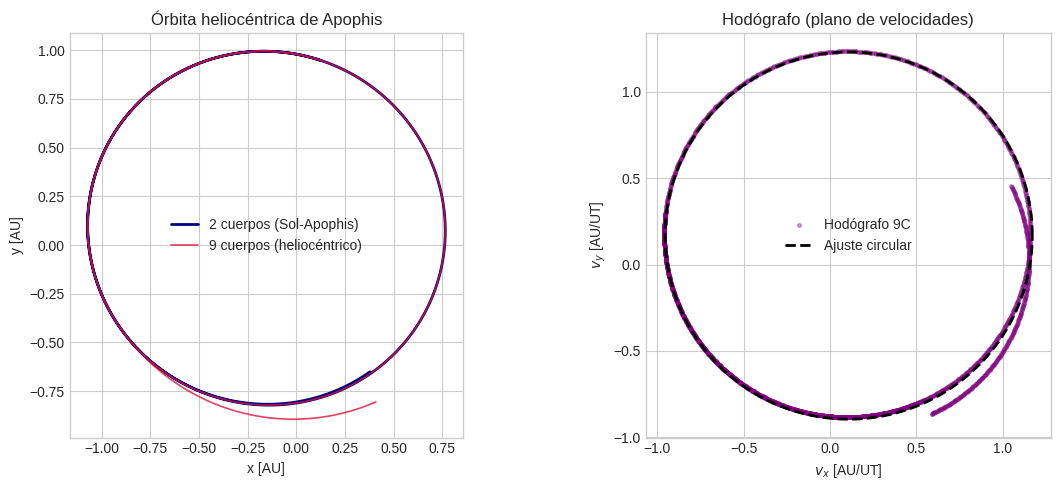

In [8]:
res2 = correr_modelo(['Sol', 'Tierra', 'Apophis'], estados_t0, duracion_dias=547, n_pasos=1700)
idx2 = res2['idx']

# Trayectoria heliocéntrica de Apophis en 2C vs 9C
rA_2 = res2['rs'][idx2['Apophis']] - res2['rs'][idx2['Sol']]
rA_9 = rs[idx9['Apophis']] - rs[idx9['Sol']]

# Hodógrafo a partir de velocidades heliocéntricas en 9C
vA_9 = vs[idx9['Apophis']] - vs[idx9['Sol']]
vxy = vA_9[:, :2]

# Ajuste de círculo (x^2 + y^2 + Ax + By + C = 0)
X = np.column_stack([vxy[:, 0], vxy[:, 1], np.ones(len(vxy))])
y = -(vxy[:, 0]**2 + vxy[:, 1]**2)
A, B, C = np.linalg.lstsq(X, y, rcond=None)[0]
xc, yc = -A/2, -B/2
R = np.sqrt(max(0.0, xc**2 + yc**2 - C))

th = np.linspace(0, 2*np.pi, 400)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].plot(rA_2[:, 0], rA_2[:, 1], color='navy', lw=2, label='2 cuerpos (Sol-Apophis)')
axes[0].plot(rA_9[:, 0], rA_9[:, 1], color='crimson', lw=1.2, alpha=0.8, label='9 cuerpos (heliocéntrico)')
axes[0].set_aspect('equal', 'box')
axes[0].set_xlabel('x [AU]')
axes[0].set_ylabel('y [AU]')
axes[0].set_title('Órbita heliocéntrica de Apophis')
axes[0].legend()

axes[1].scatter(vxy[:, 0], vxy[:, 1], s=7, alpha=0.35, color='purple', label='Hodógrafo 9C')
axes[1].plot(xc + R*np.cos(th), yc + R*np.sin(th), 'k--', lw=2, label='Ajuste circular')
axes[1].set_aspect('equal', 'box')
axes[1].set_xlabel(r'$v_x$ [AU/UT]')
axes[1].set_ylabel(r'$v_y$ [AU/UT]')
axes[1].set_title('Hodógrafo (plano de velocidades)')
axes[1].legend()

plt.tight_layout()
plt.show()


## 3. Bloque de tres cuerpos: lectura energética con Jacobi (marco CRTBP)

Aquí construimos una instantánea en torno al encuentro, normalizada al sistema Sol–Tierra, para comparar el valor de \(C_J\) de Apophis contra \(C_J(L_1)\) y \(C_J(L_2)\). Esta comparación permite una interpretación topológica de accesibilidad dinámica en el marco rotante.


In [9]:
def omega_eff(x, y, mu):
    r1 = np.sqrt((x + mu)**2 + y**2)
    r2 = np.sqrt((x - 1 + mu)**2 + y**2)
    return (1 - mu) / r1 + mu / r2 + 0.5 * (x**2 + y**2)


def jacobi(x, y, vx, vy, mu):
    return 2.0 * omega_eff(x, y, mu) - (vx**2 + vy**2)


def f_colineal(x, mu):
    return x - (1-mu)*(x+mu)/abs(x+mu)**3 - mu*(x-1+mu)/abs(x-1+mu)**3

mu = masas_canon['Tierra'] / (masas_canon['Sol'] + masas_canon['Tierra'])

# Estado cercano al mínimo refinado (usamos corrida fina 9C)
rS = rs_f[idx9['Sol'], i_min_f]
rE = rs_f[idx9['Tierra'], i_min_f]
rA = rs_f[idx9['Apophis'], i_min_f]
vS = vs_f[idx9['Sol'], i_min_f]
vE = vs_f[idx9['Tierra'], i_min_f]
vA = vs_f[idx9['Apophis'], i_min_f]

rST = rE - rS
dST = np.linalg.norm(rST)
x_hat = rST / dST

vST = vE - vS
hvec = np.cross(rST, vST)
z_hat = hvec / np.linalg.norm(hvec)
y_hat = np.cross(z_hat, x_hat)

omega_vec = hvec / (dST**2)
omega_mag = np.linalg.norm(omega_vec)

r_cm = (1 - mu) * rS + mu * rE
v_cm = (1 - mu) * vS + mu * vE

r_rel = rA - r_cm
v_rel = vA - v_cm
v_rot = v_rel - np.cross(omega_vec, r_rel)

x = np.dot(r_rel, x_hat) / dST
y = np.dot(r_rel, y_hat) / dST
vx = np.dot(v_rot, x_hat) / (dST * omega_mag)
vy = np.dot(v_rot, y_hat) / (dST * omega_mag)

CJ_apo = jacobi(x, y, vx, vy, mu)
L1 = brentq(lambda xx: f_colineal(xx, mu), 0.5, 1-mu-1e-5)
L2 = brentq(lambda xx: f_colineal(xx, mu), 1-mu+1e-5, 1.5)
CJ_L1 = jacobi(L1, 0.0, 0.0, 0.0, mu)
CJ_L2 = jacobi(L2, 0.0, 0.0, 0.0, mu)

print(f'mu (Sol-Tierra) = {mu:.6e}')
print(f'C_J(Apophis) = {CJ_apo:.6f}')
print(f'C_J(L1)      = {CJ_L1:.6f}')
print(f'C_J(L2)      = {CJ_L2:.6f}')


mu (Sol-Tierra) = 3.003481e-06
C_J(Apophis) = 2.972929
C_J(L1)      = 3.000891
C_J(L2)      = 3.000887


Visualizamos curvas de velocidad cero en un zoom de la región terrestre para contextualizar geométricamente el valor de Jacobi calculado para Apophis.


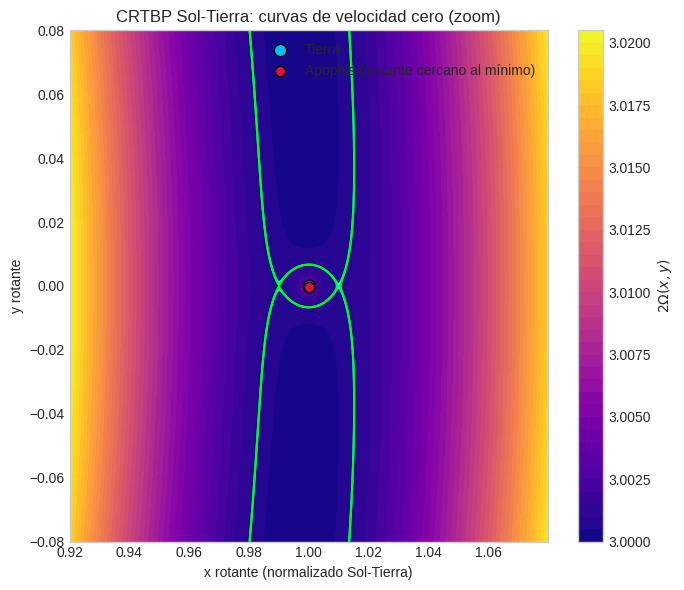

In [10]:
xg = np.linspace(1-mu-0.08, 1-mu+0.08, 350)
yg = np.linspace(-0.08, 0.08, 350)
X, Y = np.meshgrid(xg, yg)
CJ_map = np.clip(2 * omega_eff(X, Y, mu), 2.0, 5.0)

fig, ax = plt.subplots(figsize=(7, 6))
cs = ax.contourf(X, Y, CJ_map, levels=40, cmap='plasma')
niveles = sorted(set([CJ_apo, CJ_L1, CJ_L2]))
ax.contour(X, Y, CJ_map, levels=niveles, colors=['white', 'cyan', 'lime'][:len(niveles)], linewidths=1.5)
ax.scatter([1-mu], [0], color='deepskyblue', s=80, edgecolor='k', label='Tierra')
ax.scatter([x], [y], color='crimson', s=55, edgecolor='k', label='Apophis (instante cercano al mínimo)')
ax.set_xlabel('x rotante (normalizado Sol-Tierra)')
ax.set_ylabel('y rotante')
ax.set_title('CRTBP Sol-Tierra: curvas de velocidad cero (zoom)')
ax.legend(loc='upper right')
fig.colorbar(cs, ax=ax, label=r'$2\Omega(x,y)$')
plt.tight_layout()
plt.show()


## 4. Perturbaciones terrestres y ecuaciones de Gauss: variación de \(i\) y \(\Omega\)

Esta sección conecta la simulación N-cuerpos con una lectura analítica: proyectamos la aceleración perturbadora de la Tierra sobre \(\hat w\), evaluamos \(di/dt\) y \(d\Omega/dt\), e integramos para comparar contra la evolución obtenida directamente desde elementos osculadores del modelo numérico.


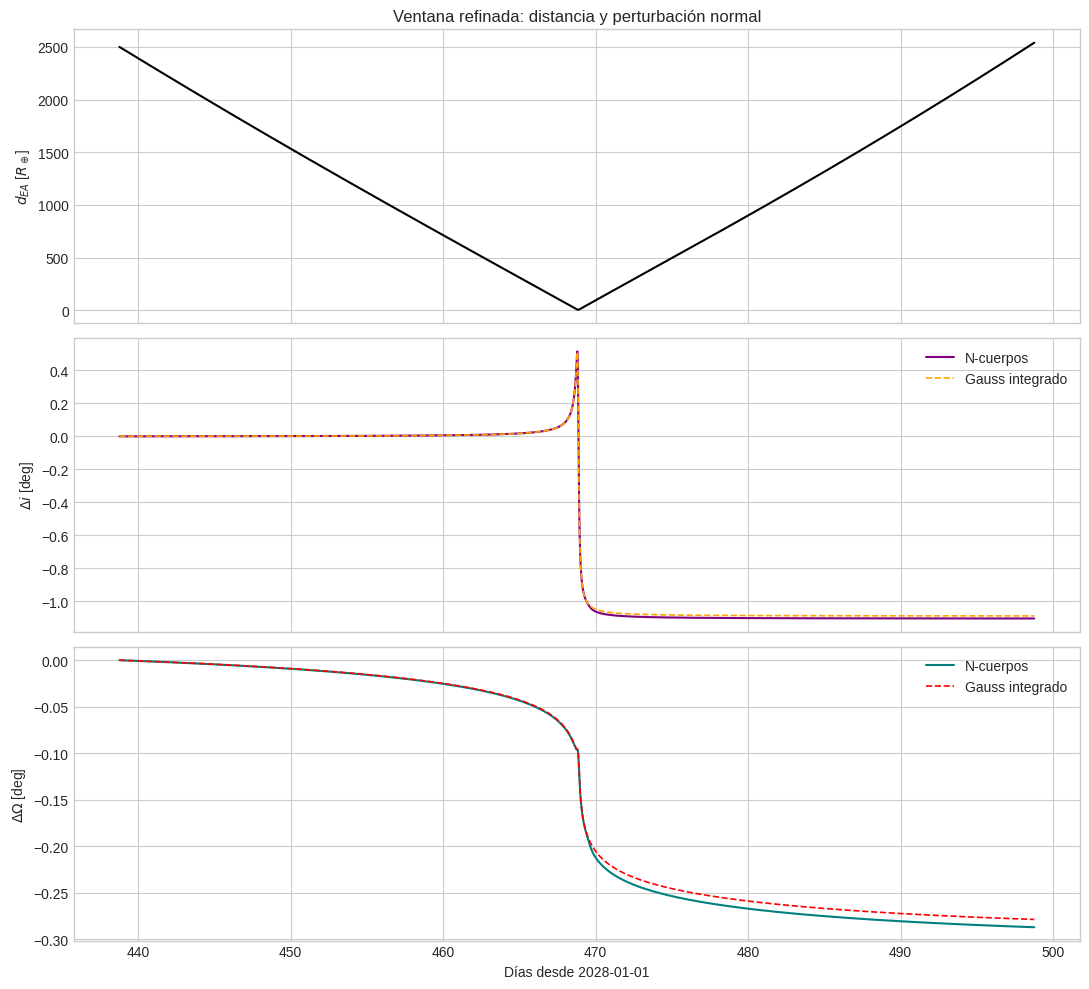

In [11]:
# Estados heliocéntricos (modelo refinado)
rA = rs_f[idx9['Apophis']] - rs_f[idx9['Sol']]
vA = vs_f[idx9['Apophis']] - vs_f[idx9['Sol']]
rE = rs_f[idx9['Tierra']] - rs_f[idx9['Sol']]

N = len(ts_rel)
aT = np.zeros((N, 3))
for k in range(N):
    dr = rE[k] - rA[k]
    d = np.linalg.norm(dr)
    aT[k] = masas_canon['Tierra'] * dr / d**3

# Elementos osculadores desde N-cuerpos
elts = np.full((N, 6), np.nan)
for k in range(N):
    estado = np.concatenate([rA[k], vA[k]])
    try:
        elts[k] = pc.estado_a_elementos(1.0, estado)  # mu_sol = 1 en canónicas
    except Exception:
        pass

p, e, inc, Omega, omega, f_true = [elts[:, j] for j in range(6)]
r_norm = np.linalg.norm(rA, axis=1)
h_vec = np.cross(rA, vA)
h_norm = np.linalg.norm(h_vec, axis=1)
w_hat = h_vec / h_norm[:, None]
W = np.einsum('ij,ij->i', aT, w_hat)

arg = omega + f_true
sin_i = np.sin(inc)

with np.errstate(divide='ignore', invalid='ignore'):
    didt = (r_norm * np.cos(arg) / h_norm) * W
    dOdt = (r_norm * np.sin(arg) / (h_norm * sin_i)) * W

# Integración temporal de Gauss (desplazamientos relativos)
i_gauss = inc[0] + cumulative_trapezoid(np.nan_to_num(didt), ts_rel, initial=0.0)
O_gauss = Omega[0] + cumulative_trapezoid(np.nan_to_num(dOdt), ts_rel, initial=0.0)

# Distancia para contexto
dEA_RE = np.linalg.norm(rs_f[idx9['Apophis']] - rs_f[idx9['Tierra']], axis=1) * AU_km / R_Earth_km

t_plot = (t_ini + ts_rel) * UT_days

fig, axes = plt.subplots(3, 1, figsize=(11, 10), sharex=True)

axes[0].plot(t_plot, dEA_RE, color='black', lw=1.5)
axes[0].set_ylabel(r'$d_{EA}$ [$R_\oplus$]')
axes[0].set_title('Ventana refinada: distancia y perturbación normal')

axes[1].plot(t_plot, np.degrees(inc - inc[0]), color='purple', lw=1.5, label='N-cuerpos')
axes[1].plot(t_plot, np.degrees(i_gauss - i_gauss[0]), '--', color='orange', lw=1.2, label='Gauss integrado')
axes[1].set_ylabel(r'$\Delta i$ [deg]')
axes[1].legend()

axes[2].plot(t_plot, np.degrees(Omega - Omega[0]), color='teal', lw=1.5, label='N-cuerpos')
axes[2].plot(t_plot, np.degrees(O_gauss - O_gauss[0]), '--', color='red', lw=1.2, label='Gauss integrado')
axes[2].set_ylabel(r'$\Delta \Omega$ [deg]')
axes[2].set_xlabel('Días desde 2028-01-01')
axes[2].legend()

plt.tight_layout()
plt.show()


## 5. Síntesis de hallazgos, limitaciones y extensiones

### Hallazgos principales

1. La estimación de \(d_{\min}\) **cambia de forma medible** al aumentar el número de cuerpos, mostrando la relevancia de perturbadores adicionales para un encuentro cercano.
2. El refinamiento temporal local en el modelo final de 9 cuerpos mejora la precisión de la fecha/distancia del evento.
3. El hodógrafo conserva una geometría aproximadamente circular en tramos dominados por dinámica heliocéntrica, pero exhibe deformación por perturbaciones durante la ventana del encuentro.
4. El análisis tipo CRTBP/Jacobi aporta una interpretación energética/topológica complementaria al resultado N-cuerpos.
5. Las ecuaciones de Gauss reproducen la tendencia de \(\Delta i\) y \(\Delta\Omega\), confirmando que la componente normal de la perturbación terrestre controla la rotación del plano orbital en la vecindad del sobrevuelo.

### Limitaciones del presente reporte

- El CRTBP aplicado aquí es una **aproximación local** (normalización instantánea), no un modelo restringido exacto para toda la ventana temporal.
- No se incluye en este cuaderno un barrido Monte Carlo completo de incertidumbre (aunque sí está implementado en notebooks especializados del repositorio).
- La precisión final depende de supuestos de masa, ventana temporal y resolución numérica adoptada.

### Extensiones futuras recomendadas

- Incorporar un bloque Monte Carlo completo en este notebook principal para cuantificar bandas de confianza de \(d_{\min}\).
- Añadir comparación con efemérides de validación independientes para cerrar el ciclo de verificación externa.
- Extender el análisis a ventanas post-2029 para estudiar sensibilidad de encuentros futuros.
